In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
from results_plots import (
    best_authors_fig7,
    extract_fig7_kernels_from_h5,
    extract_fig7_kernels_from_pt,
    integrated_gradients,
    load_eegnet_official_from_weights,
    plot_fig7,
    plot_fig9,
    plot_grouped_within_cross,
    plot_within_cross,
    integrated_gradients_torch,
)

c:\Users\zakar\OneDrive\Escritorio\MLA_EEGNet\.venv_EEGNet\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
PALETTE = [
    "#1E90FF",
    "#FFA500",
]

# Authors (CSV)
SMR_WITHIN_CSV = Path("../EEGNet_paper/SMR/4_fold_within_subject/within_subject_4fold.csv")
SMR_CROSS_CSV  = Path("../EEGNet_paper/SMR/cross_subject/cross_subject_90fold.csv")

ERN_WITHIN_CSV = Path("../EEGNet_paper/ERN/4_fold_within_subject/ern_within_subject_4fold_auc.csv")
ERN_CROSS_CSV  = Path("../EEGNet_paper/ERN/cross_subject/ern_cross_subject_folds.csv")

MRCP_WITHIN_CSV = Path("../EEGNet_paper/MRCP/4_fold_within_subject/mrcp_within_subject_4fold_auc.csv")
MRCP_CROSS_CSV  = Path("../EEGNet_paper/MRCP/cross_subject/mrcp_cross_subject_folds.csv")

P300_WITHIN_CSV = Path("../EEGNet_paper/P300/4_fold_within_subject/p300_within_subject_4fold_auc.csv")
P300_CROSS_CSV = Path("../EEGNet_paper/P300/cross_subject/p300_cross_eegnet82_20251228_170054.csv")  

# OURS (JSON)
SMR_WITHIN_O = Path("../EEGNet_ours/SMR/4_fold_within_subject/SMR_WITHIN.json")
SMR_CROSS_O  = Path("../EEGNet_ours/SMR/cross_subject/SMR_CROSS.json")

ERN_WITHIN_O = Path("../EEGNet_ours/ERN/4_fold_within_subject/ERN_WITHIN.json")
ERN_CROSS_O  = Path("../EEGNet_ours/ERN/cross_subject/ERN_CROSS.json")

MRCP_WITHIN_O = Path("../EEGNet_ours/MRCP/4_fold_within_subject/MRCP_WITHIN.json")
MRCP_CROSS_O  = Path("../EEGNet_ours/MRCP/cross_subject/MRCP_CROSS.json")

P300_WITHIN_O = Path("../EEGNet_ours/P300/4_fold_within_subject/P300_WITHIN.json")
P300_CROSS_O  = Path("../EEGNet_ours/results_p300_cross.csv")

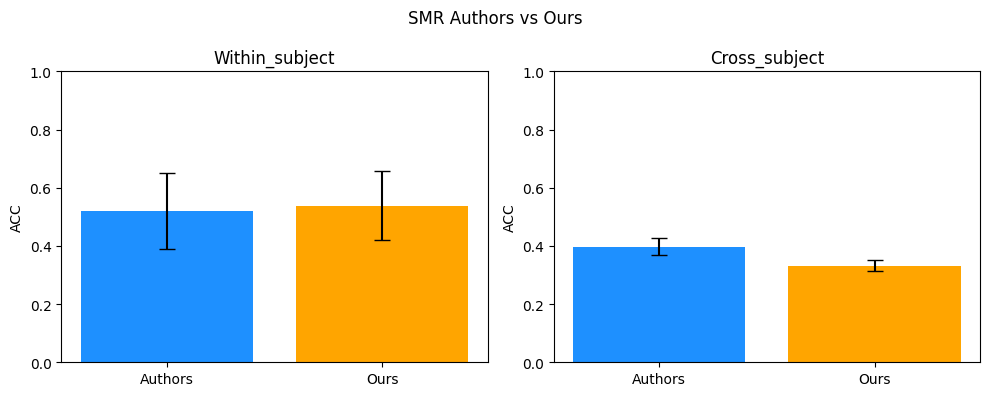

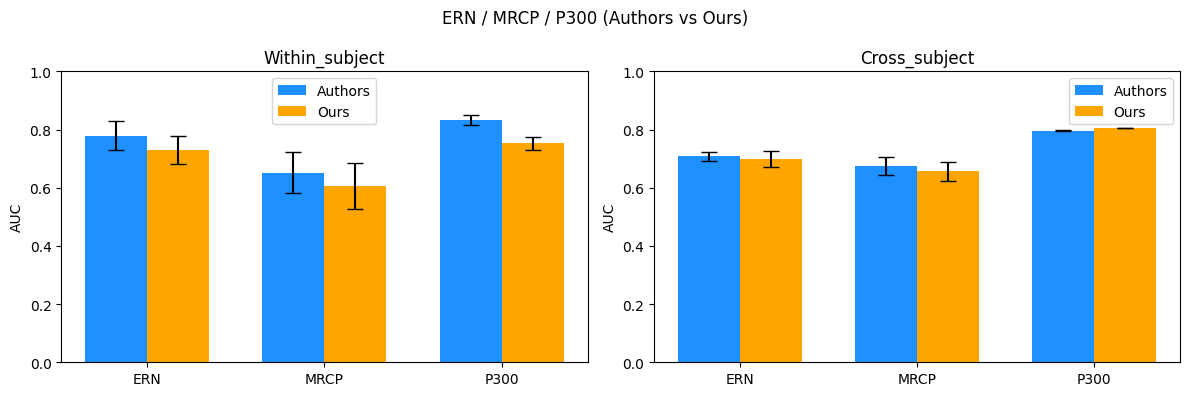

In [3]:
authors_color = PALETTE[0]
ours_color    = PALETTE[1]

plot_within_cross(
    "SMR", "acc",
    SMR_WITHIN_CSV, SMR_CROSS_CSV,
    SMR_WITHIN_O, SMR_CROSS_O,
    authors_color=authors_color,
    ours_color=ours_color
)

auc_items_auth = [
    ("ERN",  ERN_WITHIN_CSV,  ERN_CROSS_CSV),
    ("MRCP", MRCP_WITHIN_CSV, MRCP_CROSS_CSV),
    ("P300", P300_WITHIN_CSV, P300_CROSS_CSV),  
]

auc_items_ours = [
    ("ERN",  ERN_WITHIN_O,  ERN_CROSS_O),
    ("MRCP", MRCP_WITHIN_O, MRCP_CROSS_O),
    ("P300", P300_WITHIN_O, P300_CROSS_O),   
]

plot_grouped_within_cross(
    auc_items_auth,
    metric="auc",
    title="ERN / MRCP / P300 (Authors vs Ours)",
    ours_items=auc_items_ours,
    authors_color=authors_color,
    ours_color=ours_color
)

In [4]:
SUBJECT_FIG7 = 3

BEST_FOLD_AUTH, BEST_ACC_AUTH, WEIGHTS_PATH_AUTH = best_authors_fig7(
    subject=SUBJECT_FIG7,
    within_csv=SMR_WITHIN_CSV,
    metric="acc",
)

temporal_kernels_auth, spatial_filters_auth = extract_fig7_kernels_from_h5(WEIGHTS_PATH_AUTH)

In [5]:
BEST_FOLD_PT = 2
PT_CKPT_PATH = Path("../EEGNet_ours/SMR/4_fold_within_subject/smr_eegnet_ms_se_within_within_sub3_fold2.pt")

temporal_kernels_pt, spatial_filters_pt = extract_fig7_kernels_from_pt(
    PT_CKPT_PATH,
    chans=22, f1=8, d=2, klen=32,
    temporal_keys=("conv_time_short.weight", "conv_time_long.weight"),
    spatial_key="conv_spatial.weight",
)

print(f"[AUTH] kernels: temporal={temporal_kernels_auth.shape} spatial={spatial_filters_auth.shape}")
print(f"[OURS] kernels: temporal={temporal_kernels_pt.shape} spatial={spatial_filters_pt.shape}")

[AUTH] kernels: temporal=(8, 32) spatial=(8, 2, 22)
[OURS] kernels: temporal=(8, 32) spatial=(8, 2, 22)


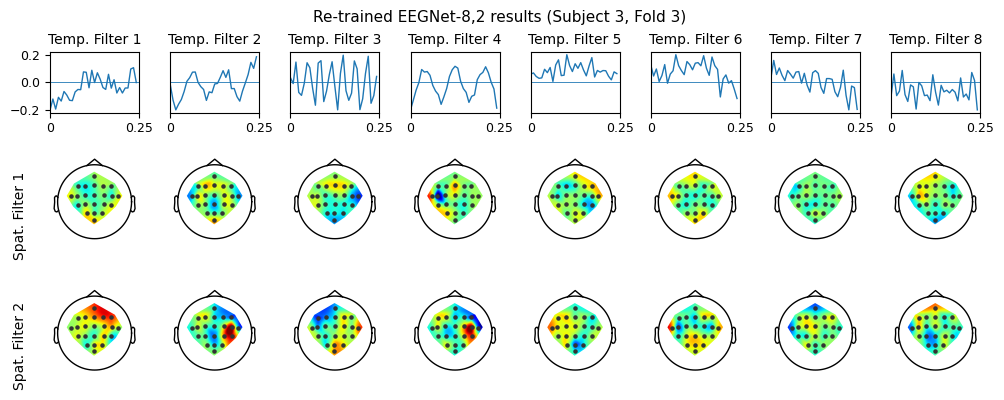

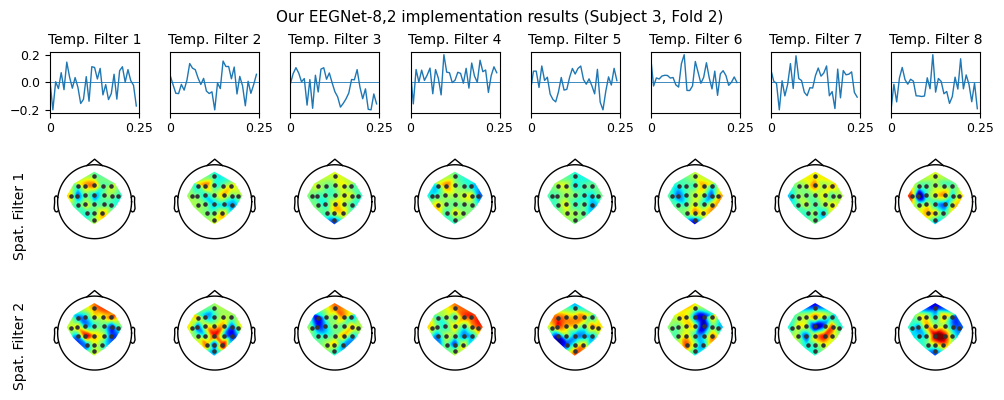

In [6]:
plot_fig7(
    temporal_kernels_auth,
    spatial_filters_auth,
    f"Re-trained EEGNet-8,2 results (Subject {SUBJECT_FIG7}, Fold {BEST_FOLD_AUTH})",
    sfreq=128.0
);

plot_fig7(
    temporal_kernels_pt,
    spatial_filters_pt,
    f"Our EEGNet-8,2 implementation results (Subject {SUBJECT_FIG7}, Fold {BEST_FOLD_PT})",
    sfreq=128.0
);

In [7]:
MRCP_CROSS_DIR = Path("../EEGNet_paper/MRCP/cross_subject")
WEIGHTS_AUTH = MRCP_CROSS_DIR / "mrcp_cross_rep03_testS03.weights.h5"

In [8]:
ARL_DIR = Path.cwd().parent / "arl-eegmodels"

model_auth, fmt_auth, params = load_eegnet_official_from_weights(
    WEIGHTS_AUTH,
    arl_dir=ARL_DIR,
    chans=19,
    samples=192,
    nb_classes=2
)

c:\Users\zakar\OneDrive\Escritorio\MLA_EEGNet\.venv_EEGNet\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
NPZ_P03 = Path("../data/MRCP/mrcp_P03_eegnet.npz")
d = np.load(NPZ_P03, allow_pickle=True)

X = d["X"].astype(np.float32)
y = d["y"].astype(int)
fs = float(d["fs"])
tmin = float(d["tmin"])
ch_names = list(d["ch_names"])


if "class_names" in d.files:
    class_names = [str(x) for x in d["class_names"]]
else:
    class_names = ["Left", "Right"]

X4 = X[..., None]

pred = model_auth.predict(X4, verbose=0)

In [10]:
p_true = pred[np.arange(len(y)), y]
pmax = pred.max(axis=1)

idxA = np.where(y == 0)[0][np.argmax(pred[y == 0, 0])]
idxB = np.where(y == 1)[0][np.argmax(pred[y == 1, 1])]
idxC = int(np.argmin(np.abs(pmax - 0.5)))

print("idxA:", idxA, "true:", class_names[y[idxA]], "P_true:", float(p_true[idxA]))
print("idxB:", idxB, "true:", class_names[y[idxB]], "P_true:", float(p_true[idxB]))
print("idxC:", idxC, "true:", class_names[y[idxC]], "P_true:", float(p_true[idxC]),
      "| pred:", class_names[int(np.argmax(pred[idxC]))], "P_pred:", float(pmax[idxC]))

idxA: 27 true: RightTap P_true: 0.804109513759613
idxB: 69 true: LeftTap P_true: 0.8138455748558044
idxC: 64 true: LeftTap P_true: 0.4990328550338745 | pred: RightTap P_pred: 0.5009670853614807


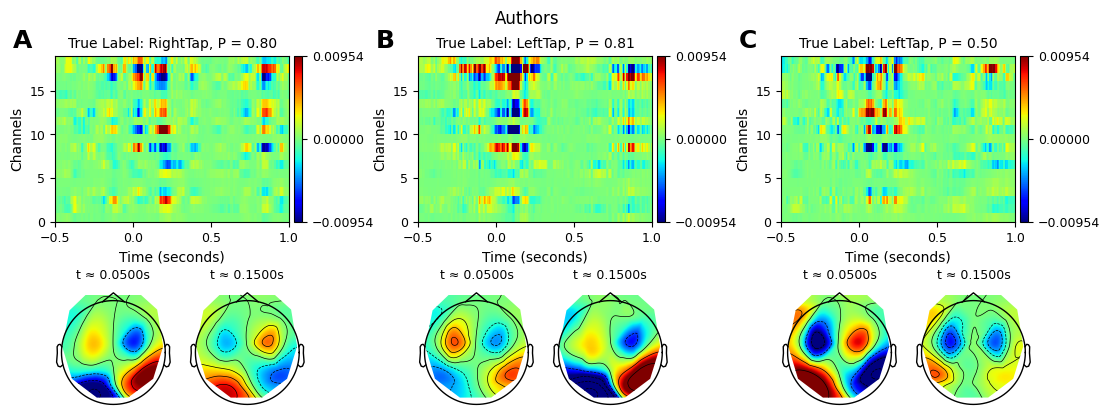

In [11]:
def trial_relevance(idx):
    x1 = X4[idx:idx+1]
    target = int(y[idx])
    ig = integrated_gradients(model_auth, x1, target_idx=target, steps=32)
    R = ig[0, :, :, 0]
    P = float(pred[idx, target])
    title = f"True Label: {class_names[target]}, P = {P:.2f}"
    return R, title

R_auth_A, titleA = trial_relevance(idxA)
R_auth_B, titleB = trial_relevance(idxB)
R_auth_C, titleC = trial_relevance(idxC)

panels_auth = [
    {"letter":"A", "title": titleA, "R": R_auth_A},
    {"letter":"B", "title": titleB, "R": R_auth_B},
    {"letter":"C", "title": titleC, "R": R_auth_C},
]

plot_fig9(
    panels_auth,
    model_label="Authors",
    sfreq=fs,
    t0=tmin,
    topo_times=(0.05, 0.15),
    ch_names=ch_names,
    cmap="jet",
);

C:\Users\zakar\AppData\Local\Temp\ipykernel_13652\1200390719.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(CKPT_OURS), map_location="cpu")


Loaded ckpt | missing: 0 | unexpected: 0
idxA: 39 true: RightTap P_true: 0.842259407043457
idxB: 55 true: LeftTap P_true: 0.774865984916687
idxC: 74 true: LeftTap P_true: 0.5007241368293762 | pred: LeftTap P_pred: 0.5007241368293762


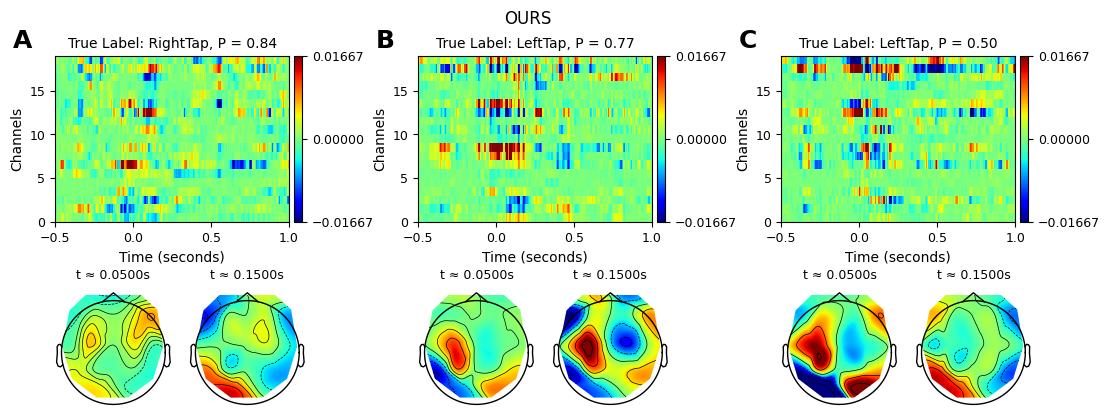

In [12]:
CKPT_OURS = Path("../EEGNet_ours/MRCP/cross_subject/mrcp_cross_fold3_test3.pt")

ROOT = Path.cwd().parent
OURS_DIR = ROOT / "EEGNet_ours"
if str(OURS_DIR) not in sys.path:
    sys.path.insert(0, str(OURS_DIR))

from models_eegnet import EEGNetMSSE

model_ours = EEGNetMSSE(
    n_channels=19,
    n_times=192,
    n_classes=2,
    F1_branch=4,
    D=2,
    kernel_len_short=32,
    kernel_len_long=64,
    dropout_p=0.5,
    se_reduction=4,
).eval()

ckpt = torch.load(str(CKPT_OURS), map_location="cpu")
state_dict = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt

state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

missing, unexpected = model_ours.load_state_dict(state_dict, strict=False)
print("Loaded ckpt | missing:", len(missing), "| unexpected:", len(unexpected))

X_t = torch.from_numpy(X).float().unsqueeze(1)

with torch.no_grad():
    logits = model_ours(X_t)
    pred = torch.softmax(logits, dim=-1).cpu().numpy()

p_true = pred[np.arange(len(y)), y]
pmax = pred.max(axis=1)

idxA = np.where(y == 0)[0][np.argmax(pred[y == 0, 0])]
idxB = np.where(y == 1)[0][np.argmax(pred[y == 1, 1])]
idxC = int(np.argmin(np.abs(pmax - 0.5)))

print("idxA:", idxA, "true:", class_names[y[idxA]], "P_true:", float(p_true[idxA]))
print("idxB:", idxB, "true:", class_names[y[idxB]], "P_true:", float(p_true[idxB]))
print("idxC:", idxC, "true:", class_names[y[idxC]], "P_true:", float(p_true[idxC]),
      "| pred:", class_names[int(np.argmax(pred[idxC]))], "P_pred:", float(pmax[idxC]))

def trial_relevance_ours(idx, steps=32):
    x1 = X_t[idx:idx+1]
    target = int(y[idx])

    ig = integrated_gradients_torch(model_ours, x1, target_idx=target, steps=steps)
    R = ig[0, 0, :, :]

    P = float(pred[idx, target])
    title = f"True Label: {class_names[target]}, P = {P:.2f}"
    return R, title

R_ours_A, titleA = trial_relevance_ours(idxA)
R_ours_B, titleB = trial_relevance_ours(idxB)
R_ours_C, titleC = trial_relevance_ours(idxC)

panels_ours = [
    {"letter":"A", "title": titleA, "R": R_ours_A},
    {"letter":"B", "title": titleB, "R": R_ours_B},
    {"letter":"C", "title": titleC, "R": R_ours_C},
]

plot_fig9(
    panels_ours,
    model_label="OURS",
    sfreq=fs,
    t0=tmin,
    topo_times=(0.05, 0.15),
    ch_names=ch_names,
    cmap="jet",
);